In [1]:
import pandas as pd
from pathlib import Path

In [2]:
figpath = Path("20260324_protein_rmsd")
figpath.mkdir(parents=True, exist_ok=True)

In [3]:
data = pd.read_parquet("/Users/apayne/Downloads/combined_docking_results/ALL_1_poses.parquet")

# Top 4 scaffolds only

In [4]:
data = data[(data.QueryData_Scaffold_ID.isin([1, 2, 3, 4]))&data.RefData_Scaffold_ID.isin([1, 2, 3, 4])]

In [5]:
# Protein RMSD histograms — one per scaffold
# For each scaffold, use only the earliest reference structure (by RefData_Date).
# Deduplicate to one row per (Reference_Structure, Query_Structure, Binding_Site_Only, Atom_Selection)
# to avoid inflating counts from the chemical-similarity parameter fan-out.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Parse dates so we can sort them
data["RefData_Date"] = pd.to_datetime(data["RefData_Date"])

# Deduplicate: one RMSD value per unique structure pair + RMSD type
rmsd_cols = ["Reference_Structure", "Query_Structure",
             "ProteinRMSDData_RMSD", "ProteinRMSDData_Binding_Site_Only",
             "ProteinRMSDData_Atom_Selection", "RefData_Scaffold_ID",
             "QueryData_Scaffold_ID",
             "RefData_Date"]
rmsd_df = (
    data[rmsd_cols]
    .drop_duplicates()
    .dropna(subset=["ProteinRMSDData_RMSD"])
    .query("ProteinRMSDData_Atom_Selection == 'heavy_atom'")
)

# For each scaffold, find the single earliest reference structure by date
earliest_refs = (
    rmsd_df.sort_values("RefData_Date")
    .groupby("RefData_Scaffold_ID")["Reference_Structure"]
    .first()
)
print("Earliest reference structure per scaffold:")
print(earliest_refs)

# Map bool to readable label for the legend
rmsd_df["Scope"] = rmsd_df["ProteinRMSDData_Binding_Site_Only"].map(
    {False: "Full chain", True: "Binding site only"}
)

Earliest reference structure per scaffold:
RefData_Scaffold_ID
1    Mpro-x0678_0A
2    Mpro-x2563_0A
3    Mpro-x0107_0A
4    Mpro-P1835_0A
Name: Reference_Structure, dtype: object


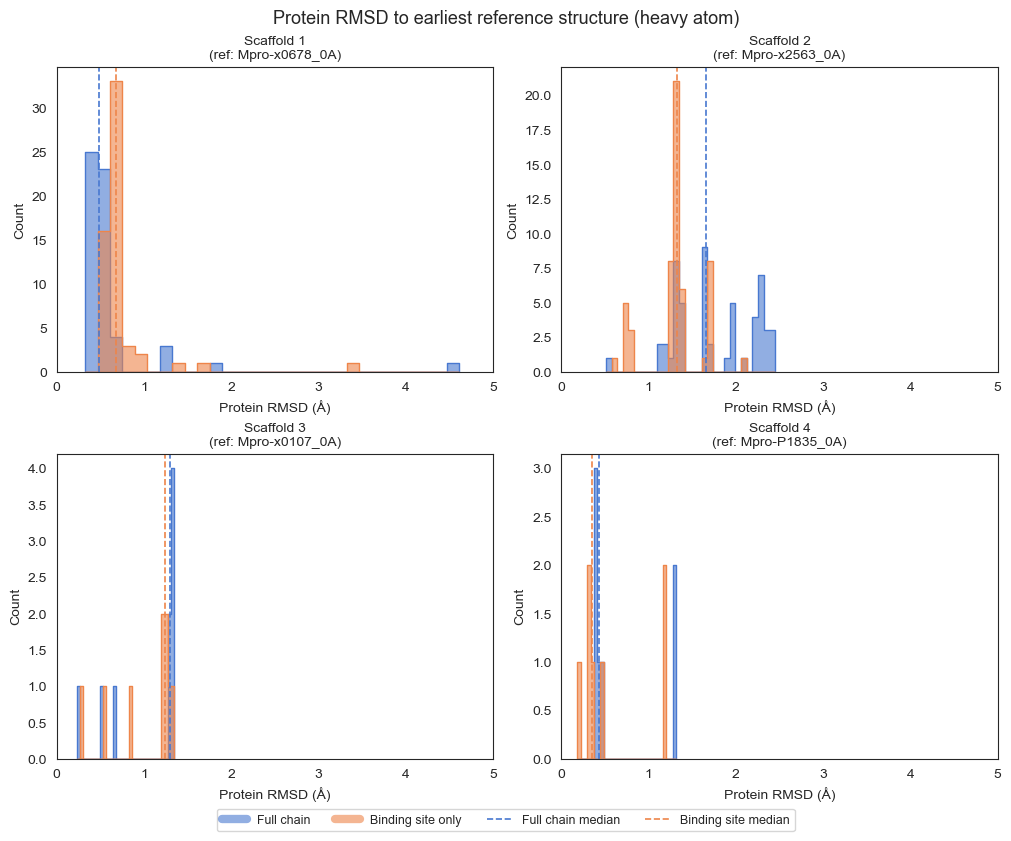

In [7]:
sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
fig.suptitle("Protein RMSD to earliest reference structure (heavy atom)", fontsize=13)

palette = {"Full chain": "#4878d0", "Binding site only": "#ee854a"}

for ax, scaffold_id in zip(axes.flat, [1, 2, 3, 4]):
    ref_structure = earliest_refs[scaffold_id]

    subset = rmsd_df[
        (rmsd_df["QueryData_Scaffold_ID"] == scaffold_id)
        &(rmsd_df["RefData_Scaffold_ID"] == scaffold_id)
        & (rmsd_df["Reference_Structure"] == ref_structure)
    ]

    sns.histplot(
        data=subset,
        x="ProteinRMSDData_RMSD",
        hue="Scope",
        palette=palette,
        bins=30,
        alpha=0.6,
        element="step",
        ax=ax,
    )

    # Median lines per series
    for scope, color in palette.items():
        med = subset.loc[subset["Scope"] == scope, "ProteinRMSDData_RMSD"].median()
        ax.axvline(med, color=color, linestyle="--", linewidth=1.2, label=f"{scope} median: {med:.2f} Å")

    ax.set_title(f"Scaffold {scaffold_id}\n(ref: {ref_structure})", fontsize=10)
    ax.set_xlabel("Protein RMSD (Å)")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 5)
    if ax.get_legend():
        ax.get_legend().remove()

# Single shared legend outside the grid
handles = [
    plt.Line2D([0], [0], color=palette["Full chain"], linewidth=6, alpha=0.6, label="Full chain"),
    plt.Line2D([0], [0], color=palette["Binding site only"], linewidth=6, alpha=0.6, label="Binding site only"),
    plt.Line2D([0], [0], color=palette["Full chain"], linestyle="--", linewidth=1.2, label="Full chain median"),
    plt.Line2D([0], [0], color=palette["Binding site only"], linestyle="--", linewidth=1.2, label="Binding site median"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.04), fontsize=9)


plt.savefig(figpath / "protein_rmsd_per_scaffold.png", dpi=150, bbox_inches="tight")
plt.show()

# RMSD vs date of collection

In [8]:
# Build a structure -> date lookup from the deduplicated rmsd_df
# (RefData_Date is the date for whichever structure appears as Reference_Structure)
structure_date = (
    rmsd_df[["Reference_Structure", "RefData_Date"]]
    .drop_duplicates()
    .set_index("Reference_Structure")["RefData_Date"]
)

# Add the query structure's collection date by mapping Query_Structure through the same lookup
rmsd_df["Query_Date"] = rmsd_df["Query_Structure"].map(structure_date)


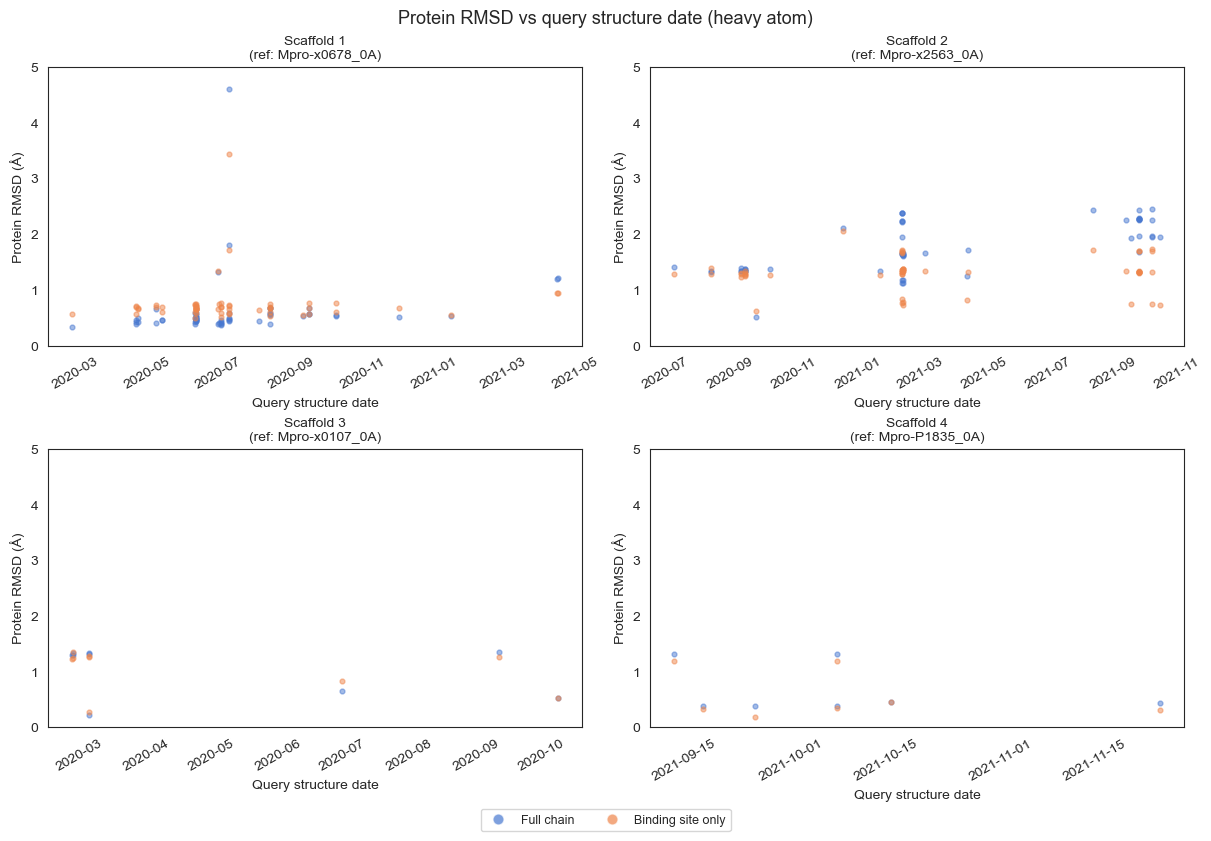

In [9]:
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig2.suptitle("Protein RMSD vs query structure date (heavy atom)", fontsize=13)

for ax, scaffold_id in zip(axes2.flat, [1, 2, 3, 4]):
    ref_structure = earliest_refs[scaffold_id]

    subset = rmsd_df[
        (rmsd_df["QueryData_Scaffold_ID"] == scaffold_id)
        & (rmsd_df["RefData_Scaffold_ID"] == scaffold_id)
        & (rmsd_df["Reference_Structure"] == ref_structure)
    ].dropna(subset=["Query_Date"])

    for scope, color in palette.items():
        s = subset[subset["Scope"] == scope]
        ax.scatter(
            s["Query_Date"],
            s["ProteinRMSDData_RMSD"],
            color=color,
            alpha=0.5,
            s=12,
            label=scope,
        )

    ax.set_title(f"Scaffold {scaffold_id}\n(ref: {ref_structure})", fontsize=10)
    ax.set_xlabel("Query structure date")
    ax.set_ylabel("Protein RMSD (Å)")
    ax.set_ylim(0, 5)
    ax.tick_params(axis="x", rotation=30)
    if ax.get_legend():
        ax.get_legend().remove()

handles2 = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=palette["Full chain"],
               markersize=8, alpha=0.7, label="Full chain"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=palette["Binding site only"],
               markersize=8, alpha=0.7, label="Binding site only"),
]
fig2.legend(handles=handles2, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04), fontsize=9)

plt.savefig(figpath / "protein_rmsd_vs_date_per_scaffold.png", dpi=150, bbox_inches="tight")
plt.show()

# Analyze the largest Scaffold 1 RMSD

In [10]:
rmsd_df[(rmsd_df["RefData_Scaffold_ID"] == 1) & (rmsd_df["QueryData_Scaffold_ID"] == 1) & (rmsd_df["Reference_Structure"] == earliest_refs[1])]

,Reference_Structure,Query_Structure,ProteinRMSDData_RMSD,ProteinRMSDData_Binding_Site_Only,ProteinRMSDData_Atom_Selection,RefData_Scaffold_ID,QueryData_Scaffold_ID,RefData_Date,Scope,Query_Date
71140,Mpro-x0678_0A,Mpro-x11317_0A,0.6828,True,heavy_atom,1,1,2020-02-27 01:46:57,Binding site only,2020-08-13 16:46:52
71141,Mpro-x0678_0A,Mpro-x11317_0A,0.5823,False,heavy_atom,1,1,2020-02-27 01:46:57,Full chain,2020-08-13 16:46:52
80804,Mpro-x0678_0A,Mpro-x10395_0A,0.6520,True,heavy_atom,1,1,2020-02-27 01:46:57,Binding site only,2020-06-11 19:31:10
80805,Mpro-x0678_0A,Mpro-x10395_0A,0.5769,False,heavy_atom,1,1,2020-02-27 01:46:57,Full chain,2020-06-11 19:31:10
113004,Mpro-x0678_0A,Mpro-x10888_0A,0.5836,True,heavy_atom,1,1,2020-02-27 01:46:57,Binding site only,2020-07-02 22:10:48
...,...,...,...,...,...,...,...,...,...,...
1246405,Mpro-x0678_0A,Mpro-x2569_0A,0.3951,False,heavy_atom,1,1,2020-02-27 01:46:57,Full chain,2020-04-21 20:14:50
1252840,Mpro-x0678_0A,Mpro-x11801_0A,0.6045,True,heavy_atom,1,1,2020-02-27 01:46:57,Binding site only,2020-10-09 00:20:59
1252841,Mpro-x0678_0A,Mpro-x11801_0A,0.5400,False,heavy_atom,1,1,2020-02-27 01:46:57,Full chain,2020-10-09 00:20:59
1268944,Mpro-x0678_0A,Mpro-x11011_0A,0.5648,True,heavy_atom,1,1,2020-02-27 01:46:57,Binding site only,2020-07-10 05:29:49


# MDTraj heavy-atom RMSD utility

I'm just double checking with mdtraj that the RMSD values are reasonable and consistent with the ones I calculated using MD analysis.

In [20]:
import mdtraj as md
from pathlib import Path


def calculate_heavy_atom_rmsd(ref_pdb: str | Path, mobile_pdb: str | Path, chain: str = "A") -> float:
    """
    Calculate the heavy-atom RMSD between two protein PDB files after superposition.

    Loads both structures with MDTraj, selects all non-hydrogen protein atoms on
    the specified chain, superposses the mobile onto the reference, and returns
    the RMSD in Ångströms.

    Parameters
    ----------
    ref_pdb : str or Path
        Path to the reference PDB file.
    mobile_pdb : str or Path
        Path to the mobile PDB file.
    chain : str
        Chain ID to restrict the selection to (default: "A").

    Returns
    -------
    float
        Heavy-atom RMSD in Ångströms after superposition.
    """
    ref = md.load(str(ref_pdb))
    mobile = md.load(str(mobile_pdb))

    # Select heavy protein atoms on the specified chain (MDTraj uses 0-based chain index,
    # so we match by chain ID string via the topology)
    chain_indices = [c.index for c in ref.topology.chains if c.chain_id == chain]
    if not chain_indices:
        import warnings
        warnings.warn(f"Chain '{chain}' not found in {Path(ref_pdb).name}; using all chains.")
        sel = "protein and not element H"
    else:
        sel = f"protein and not element H and chainid {' '.join(str(i) for i in chain_indices)}"

    ref_atoms = ref.topology.select(sel)
    mobile_atoms = mobile.topology.select(sel)

    if len(ref_atoms) != len(mobile_atoms):
        import warnings
        warnings.warn(
            f"Atom count mismatch: {Path(ref_pdb).name} has {len(ref_atoms)}, "
            f"{Path(mobile_pdb).name} has {len(mobile_atoms)}. "
            f"Trimming to common residues."
        )
        ref_resids = set(ref.topology.atom(i).residue.resSeq for i in ref_atoms)
        mob_resids = set(mobile.topology.atom(i).residue.resSeq for i in mobile_atoms)
        common = ref_resids & mob_resids
        ref_atoms = ref.topology.select(
            sel + " and resSeq " + " ".join(str(r) for r in sorted(common))
        )
        mobile_atoms = mobile.topology.select(
            sel + " and resSeq " + " ".join(str(r) for r in sorted(common))
        )

    # Superpose and compute RMSD (MDTraj returns RMSD in nm → convert to Å)
    mobile_superposed = mobile.superpose(ref, atom_indices=mobile_atoms, ref_atom_indices=ref_atoms)
    rmsd_nm = md.rmsd(mobile_superposed, ref, atom_indices=ref_atoms)[0]
    return float(rmsd_nm * 10)  # nm → Å

In [21]:
import mdtraj as md
from pathlib import Path
ref_pdb = "/Users/apayne/science/sars-cov-2-retro-paper-asap/mpro_fragalysis-04-01-24_curated_cache_fixed/Mpro-x0678_0A-6ea0b1f3585aecbf7bce5ec98859c5f2315ac99441599d302c585636ea075494+SIURWXONEBYXJD-YAQRNVERNA-N/Mpro-x0678_0A.pdb"
mobile_pdb = "/Users/apayne/science/sars-cov-2-retro-paper-asap/mpro_fragalysis-04-01-24_curated_cache_fixed/Mpro-x11013_0A-eec29c3317fe21586e5ccb6b67197ea7dc7d1b26ac0c49e1a6e8db3f374bc621+VUGOQWLHGHMVIW-HCKMINDGNA-N/Mpro-x11013_0A.pdb"
chain = "A"
ref = md.load(str(ref_pdb))
mobile = md.load(str(mobile_pdb))

# Select heavy protein atoms on the specified chain (MDTraj uses 0-based chain index,
# so we match by chain ID string via the topology)
chain_indices = [c.index for c in ref.topology.chains if c.chain_id == chain]
if not chain_indices:
    import warnings
    warnings.warn(f"Chain '{chain}' not found in {Path(ref_pdb).name}; using all chains.")
    sel = "protein and not element H"
else:
    sel = f"protein and not element H and chainid {' '.join(str(i) for i in chain_indices)}"

ref_atoms = ref.topology.select(sel)
mobile_atoms = mobile.topology.select(sel)
atoms = set(ref_atoms) & set(mobile_atoms)

In [22]:
# Superpose and compute RMSD (MDTraj returns RMSD in nm → convert to Å)
# atom_indices must be sorted — use the corrected ref_atoms/mobile_atoms directly
mobile_superposed = mobile.superpose(ref, atom_indices=sorted(atoms), ref_atom_indices=sorted(atoms))
rmsd_nm = md.rmsd(mobile_superposed, ref, atom_indices=sorted(atoms))[0]

In [23]:
rmsd_nm * 10

4.609593749046326